# Proyecto Minería de Datos: Steam Games (Dataset Filtrado)

Este cuaderno contiene el análisis exploratorio y la visualización del dataset de juegos de Steam filtrado por valoraciones positivas.

--- 

## 1. Descripción del Dataset

El dataset actual (`data_top_positives.csv`) es una versión optimizada del conjunto de datos categorizado. Se han seleccionado exclusivamente los juegos con reseñas de usuario **'Very Positive'** (Muy Positivas) y **'Overwhelmingly Positive'** (Extremadamente Positivas).

### Características Clave:
- **Registros:** ~21,390 juegos de alto rendimiento.
- **Columnas base:** Datos técnicos, comerciales y métricas de juego (CCU, Playtime).
- **Categorización (One-Hot Encoding):** Géneros (`genre_...`) y etiquetas (`tag_...`) ya transformados en variables binarias.
- **Propósito:** Identificar patrones de éxito y asociación en los títulos mejor valorados de la plataforma.

In [208]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# Intentar importar librerías necesarias, instalar si faltan
try:
    import seaborn as sns
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    print("📦 Instalando librerías faltantes (seaborn, mlxtend)...")
    os.system('pip install seaborn mlxtend')
    import seaborn as sns
    from mlxtend.frequent_patterns import apriori, association_rules

# Configuración global
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = [12, 6]

# Carga del dataset
file_path = 'data_top_positives.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Dataset cargado correctamente: {df.shape[0]} registros.")
else:
    print(f"❌ No se encontró el archivo: {file_path}")

✅ Dataset cargado correctamente: 21390 registros.


In [209]:
# Vista rápida de los datos
cols_interes = ['Name', 'Release date', 'Price', 'Estimated owners', 'Peak CCU', 'review_score_cat']
df[cols_interes].head(10)

,Name,Release date,Price,Estimated owners,Peak CCU,review_score_cat
0,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",5.24,0 - 20000,0,Very Positive
1,Armored Brigade II,"Apr 8, 2025",35.99,0 - 20000,8,Very Positive
2,OMNIMUS,"Sep 25, 2019",0.99,0 - 20000,0,Very Positive
3,Fantasy General II,"Sep 5, 2019",13.99,100000 - 200000,13,Very Positive
4,"Forests, Fields and Fortresses","Apr 5, 2023",1.49,0 - 20000,0,Very Positive
5,Bad North: Jotunn Edition,"Nov 16, 2018",2.99,500000 - 1000000,64,Very Positive
6,Lucky Night: Texas Hold'em VR,"Jul 26, 2017",0.00,100000 - 200000,0,Very Positive
7,Wizard Shrimp,"Dec 13, 2024",2.99,0 - 20000,1,Very Positive
8,Pixel Game Maker Series Werewolf Princess Kaguya,"Dec 20, 2020",9.99,0 - 20000,0,Very Positive
9,The Metronomicon: Slay The Dance Floor,"Sep 29, 2016",4.99,20000 - 50000,1,Very Positive


--- 

## 2. Suite de Visualización de Datos

### 2.1 Análisis Exploratorio Inicial

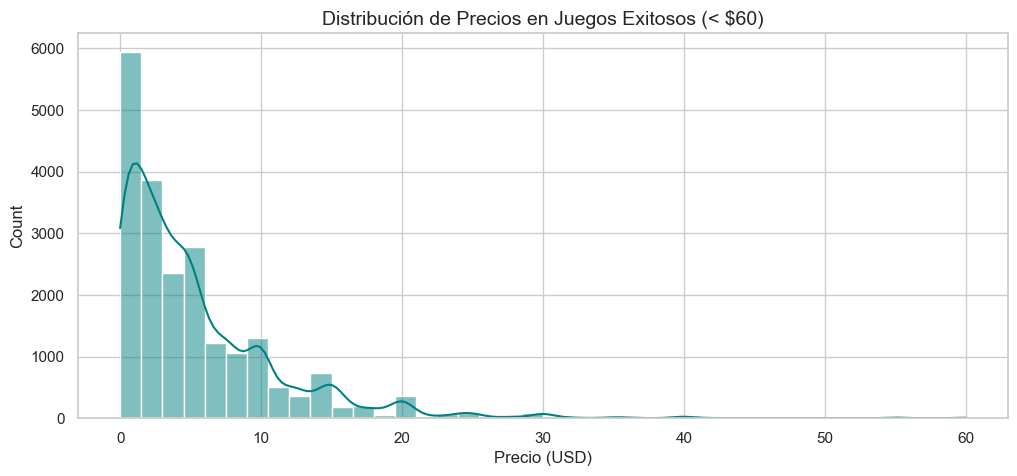

In [210]:
# A. Distribución de Precios
plt.figure(figsize=(12, 5))
sns.histplot(df[df['Price'] < 60]['Price'], bins=40, kde=True, color='teal')
plt.title('Distribución de Precios en Juegos Exitosos (< $60)', fontsize=14)
plt.xlabel('Precio (USD)')
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3632077469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma')


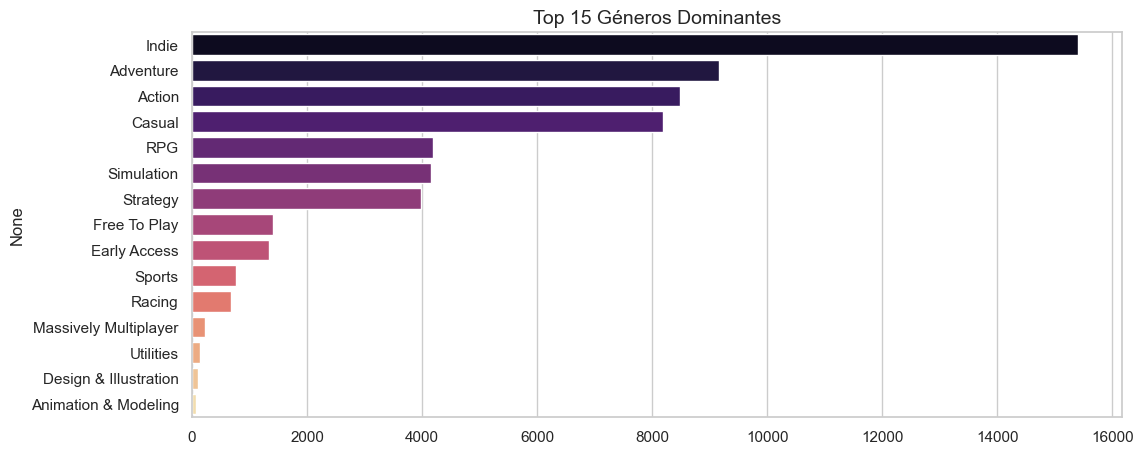

In [211]:
# B. Top 15 Géneros más comunes
genre_cols = [col for col in df.columns if col.startswith('genre_')]
genre_counts = df[genre_cols].sum().sort_values(ascending=False).head(15)
genre_counts.index = [name.replace('genre_', '') for name in genre_counts.index]

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma')
plt.title('Top 15 Géneros Dominantes', fontsize=14)
plt.show()

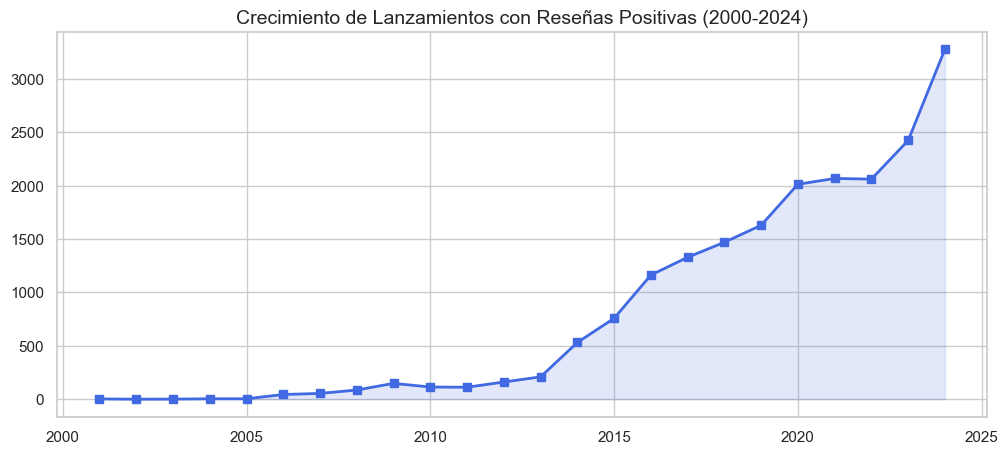

In [212]:
# C. Evolución Temporal de Lanzamientos Exitosos
yearly_counts = df[(df['Release_year'] > 2000) & (df['Release_year'] <= 2024)]['Release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='s', color='royalblue', linewidth=2)
plt.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.15, color='royalblue')
plt.title('Crecimiento de Lanzamientos con Reseñas Positivas (2000-2024)', fontsize=14)
plt.show()

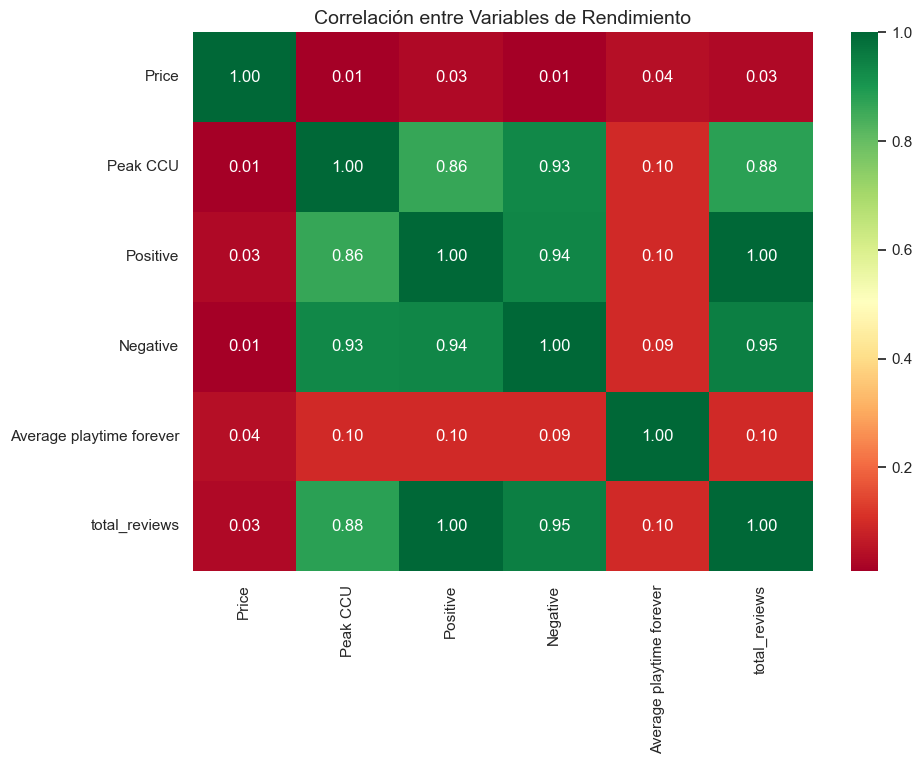

In [213]:
# D. Mapa de Correlación entre Métricas Numéricas
num_cols = ['Price', 'Peak CCU', 'Positive', 'Negative', 'Average playtime forever', 'total_reviews']
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlación entre Variables de Rendimiento', fontsize=14)
plt.show()

### 2.2 Visualizaciones Avanzadas

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\815856711.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='viridis')


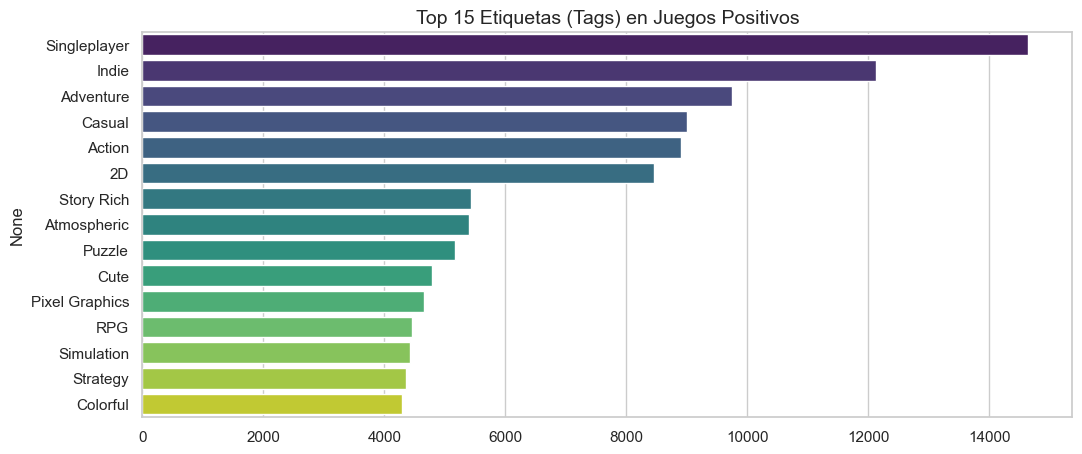

In [214]:
# E. Top 15 Etiquetas (Tags) más comunes
tag_cols = [col for col in df.columns if col.startswith('tag_')]
tag_counts = df[tag_cols].sum().sort_values(ascending=False).head(15)
tag_counts.index = [name.replace('tag_', '') for name in tag_counts.index]

plt.figure(figsize=(12, 5))
sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='viridis')
plt.title('Top 15 Etiquetas (Tags) en Juegos Positivos', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\1862016123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sales_cat', palette='Set2', order=df['sales_cat'].value_counts().index)


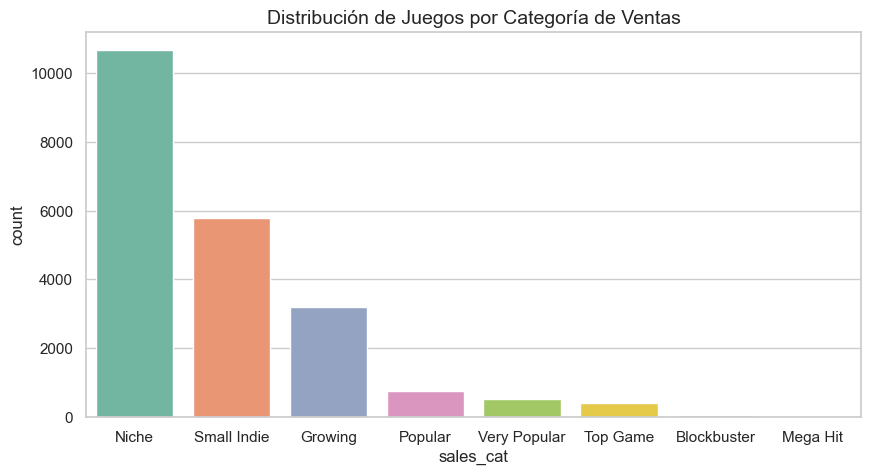

In [215]:
# F. Distribución por Categoría de Ventas (sales_cat)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='sales_cat', palette='Set2', order=df['sales_cat'].value_counts().index)
plt.title('Distribución de Juegos por Categoría de Ventas', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3233835131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Release_season', palette='coolwarm', order=season_order)


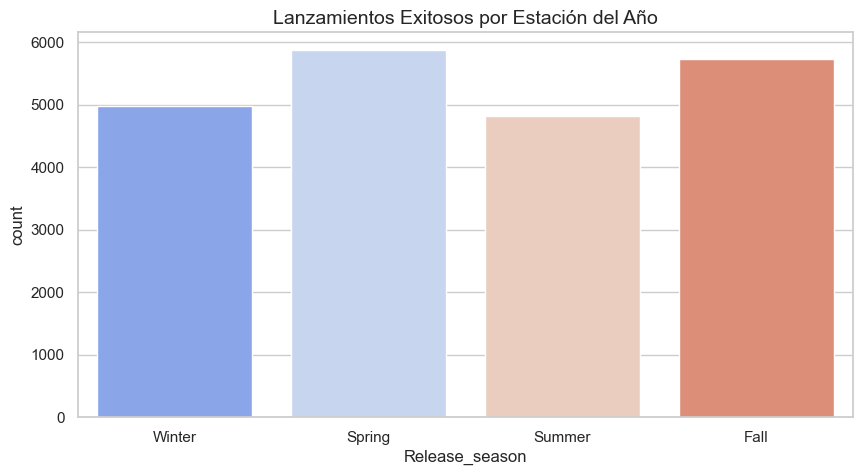

In [216]:
# G. Análisis de Estacionalidad de Lanzamientos
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Release_season', palette='coolwarm', order=season_order)
plt.title('Lanzamientos Exitosos por Estación del Año', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3518217859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sales_cat', y='Average playtime forever', palette='Set3')


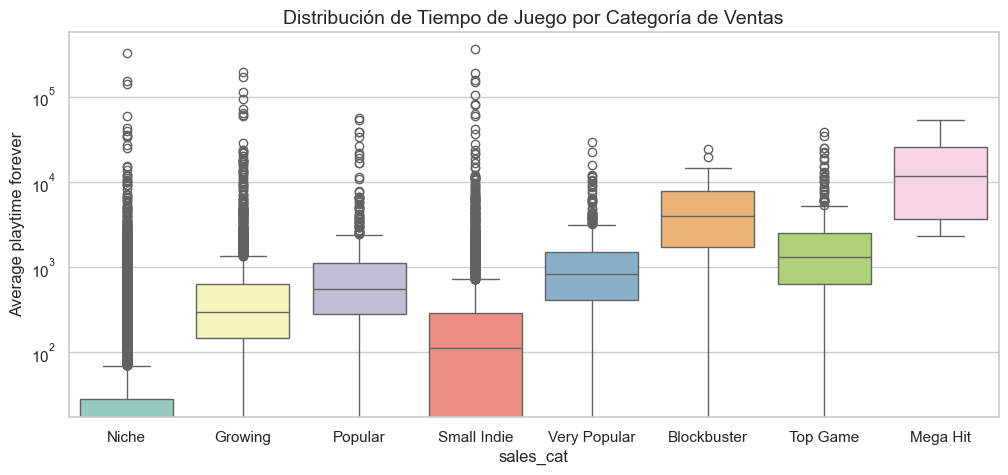

In [217]:
# H. Tiempo de Juego vs Categoría de Ventas
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='sales_cat', y='Average playtime forever', palette='Set3')
plt.yscale('log')
plt.title('Distribución de Tiempo de Juego por Categoría de Ventas', fontsize=14)
plt.show()

--- 

## 3. Análisis de Reglas de Asociación (Apriori)

Buscamos relaciones entre géneros y etiquetas que definen a los juegos exitosos.

In [225]:
# 1. Preparación: Limpiar redundancias entre 'genre_' y 'tag_'
binary_cols = [col for col in df.columns if col.startswith('genre_') or col.startswith('tag_')]
df_binary = df[binary_cols].copy()

# Renombramos las columnas quitando los prefijos
df_binary.columns = [col.replace('genre_', '').replace('tag_', '') for col in df_binary.columns]

# Agrupamos por nombre de columna
df_binary = df_binary.T.groupby(level=0).max().T

# Seleccionamos los 50 elementos más frecuentes
top_elements = df_binary.sum().sort_values(ascending=False).head(50).index
df_filtered_binary = df_binary[top_elements]

# 2. Ejecución de Apriori
print("⌛ Calculando combinaciones frecuentes... ")
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(df_filtered_binary.astype(bool), min_support=0.05, use_colnames=True)

# 3. Generación de Reglas
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Ordenamos por 'lift' para los resultados (ya sin redundancias artificiales)
rules = rules.sort_values(by='lift', ascending=False)

print(f"✅ Se han generado {len(rules)} reglas de asociación.")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))


⌛ Calculando combinaciones frecuentes... 
✅ Se han generado 2288 reglas de asociación.


,antecedents,consequents,support,confidence,lift
1058,"frozenset({Adventure, Psychological Horror})",frozenset({Horror}),0.052595,0.750000,5.628947
1063,frozenset({Horror}),"frozenset({Adventure, Psychological Horror})",0.052595,0.394737,5.628947
554,"frozenset({Horror, Indie})",frozenset({Psychological Horror}),0.058719,0.545613,5.507622
557,frozenset({Psychological Horror}),"frozenset({Horror, Indie})",0.058719,0.592732,5.507622
1062,frozenset({Psychological Horror}),"frozenset({Adventure, Horror})",0.052595,0.530911,5.438785
1059,"frozenset({Adventure, Horror})",frozenset({Psychological Horror}),0.052595,0.538793,5.438785
227,frozenset({2D Platformer}),frozenset({Platformer}),0.055213,0.669122,5.431695
226,frozenset({Platformer}),frozenset({2D Platformer}),0.055213,0.448197,5.431695
556,frozenset({Horror}),"frozenset({Psychological Horror, Indie})",0.058719,0.440702,5.334811
555,"frozenset({Psychological Horror, Indie})",frozenset({Horror}),0.058719,0.710809,5.334811


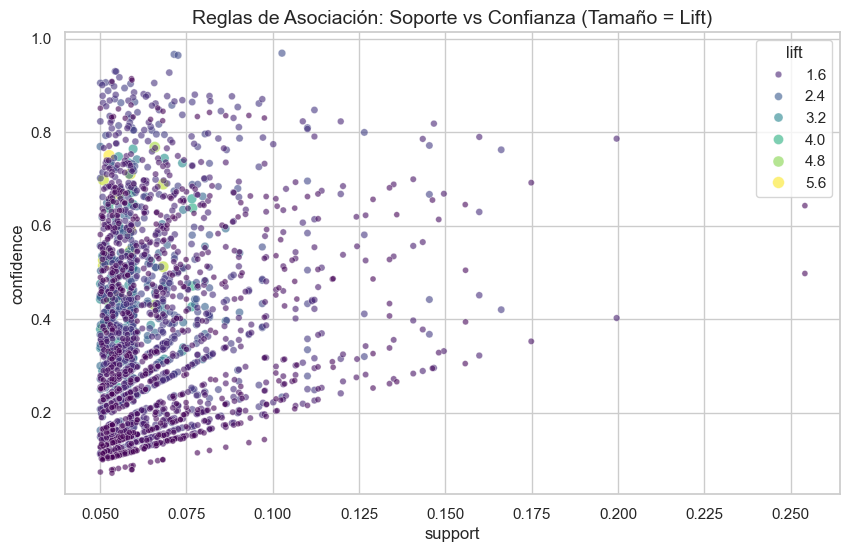

In [228]:
# Visualización: Soporte vs Confianza
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x="support", y="confidence", size="lift", hue="lift", palette="viridis", alpha=0.6)
plt.title('Reglas de Asociación: Soporte vs Confianza (Tamaño = Lift)', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3133016727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rules, x='lift', y='rule', palette='flare')


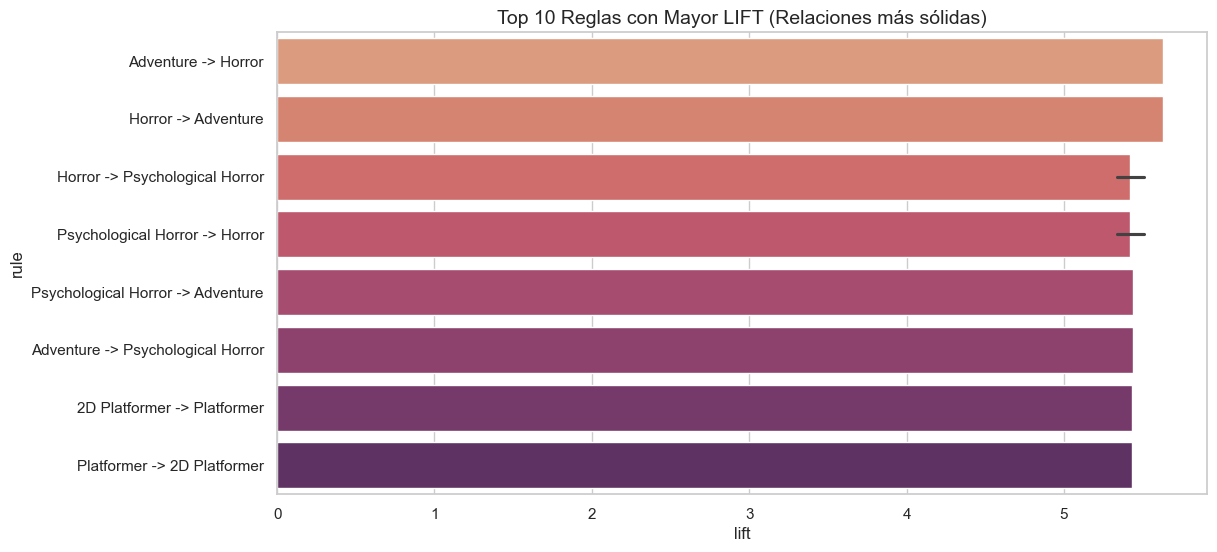

In [229]:
# Top 10 Reglas por Lift
top_rules = rules.head(10).copy()
top_rules['rule'] = top_rules['antecedents'].apply(lambda x: list(x)[0]) + " -> " + top_rules['consequents'].apply(lambda x: list(x)[0])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_rules, x='lift', y='rule', palette='flare')
plt.title('Top 10 Reglas con Mayor LIFT (Relaciones más sólidas)', fontsize=14)
plt.show()

### 3.1 Filtrado de Reglas Obvias y Descubrimiento de Nichos

Al ejecutar el algoritmo Apriori sobre los géneros y etiquetas de los juegos, es común que las reglas con mayor confianza correspondan a jerarquías naturales de clasificación (por ejemplo, `2D Platformer -> Platformer` o `Psychological Horror -> Horror`) o a conceptos sumamente amplios que aplican a casi cualquier juego moderno (como `Indie` o `Singleplayer`).

Aunque estas reglas son matemáticamente precisas, aportan poco valor analítico o de negocio. Para encontrar los verdaderos **diamantes ocultos** (asociaciones que revelan nichos de mercado específicos o combinaciones de mecánicas que los jugadores buscan juntas), aplicaremos dos estrategias de filtrado avanzado:
1. **Exclusión de etiquetas genéricas ("Stop-Tags"):** Retirar de las reglas aquellas etiquetas masivas que no aportan diferenciación.
2. **Análisis de reglas complejas:** Buscar combinaciones de 3 o más elementos, las cuales suelen describir sub-géneros o perfiles de juego altamente específicos.


In [230]:
# ==============================================================================
# ESTRATEGIA 1: Eliminación de Etiquetas Genéricas o Jerárquicas
# ==============================================================================

# Definimos las palabras clave a ignorar (ajustables según los hallazgos)
stop_tags = {'Indie', 'Singleplayer', 'Multiplayer', 'Horror', 'Platformer', 'Action', 'Adventure'}

def sin_etiquetas_genericas(itemset):
    """Retorna True si el conjunto NO contiene ninguna etiqueta de la lista stop_tags"""
    return not any(item in stop_tags for item in itemset)

# Filtramos conservando solo las reglas que pasan la validación en antecedente y consecuente
reglas_nicho = rules[
    rules['antecedents'].apply(sin_etiquetas_genericas) & 
    rules['consequents'].apply(sin_etiquetas_genericas)
].copy()

# Generamos las cadenas de texto para fácil lectura
reglas_nicho['antecedents_str'] = reglas_nicho['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_nicho['consequents_str'] = reglas_nicho['consequents'].apply(lambda x: ', '.join(list(x)))
reglas_nicho['rule'] = reglas_nicho['antecedents_str'] + " -> " + reglas_nicho['consequents_str']

print(f"🎮 Se encontraron {len(reglas_nicho)} reglas de nicho (sin etiquetas genéricas).")
display(reglas_nicho[['rule', 'support', 'confidence', 'lift']].head(15))


🎮 Se encontraron 236 reglas de nicho (sin etiquetas genéricas).


,rule,support,confidence,lift
217,Visual Novel -> Anime,0.076765,0.638166,3.916890
216,Anime -> Visual Novel,0.076765,0.471162,3.916890
206,Comedy -> Funny,0.076578,0.657567,3.664764
207,Funny -> Comedy,0.076578,0.426785,3.664764
1191,"Pixel Graphics -> 2D, Retro",0.068630,0.314954,3.416259
1190,"2D, Retro -> Pixel Graphics",0.068630,0.744422,3.416259
1151,"Family Friendly -> Colorful, Casual",0.052501,0.406001,3.268487
1146,"Colorful, Casual -> Family Friendly",0.052501,0.422657,3.268487
1140,"Colorful, Casual -> Relaxing",0.052314,0.421152,3.185444
1145,"Relaxing -> Colorful, Casual",0.052314,0.395686,3.185444


#### Análisis de Asociaciones Complejas (Clústers de Género)
Las relaciones sencillas de un ítem a otro suelen ser deductibles. Sin embargo, cuando analizamos reglas que involucran 3 o más elementos en conjunto, logramos visualizar la formación de "Clústers de Género" o perfiles de juegos que poseen comunidades sólidas. Esto permite identificar qué mecánicas conjuntas son un éxito probado.


In [232]:
# ==============================================================================
# ESTRATEGIA 2: Búsqueda de Nichos Complejos (3 o más elementos)
# ==============================================================================

# Filtramos reglas que en total (antecedentes + consecuentes) tengan 3 o más atributos
reglas_complejas = rules[rules['antecedents'].apply(len) + rules['consequents'].apply(len) >= 3].copy()

# Ordenamos por 'lift' para ver cuáles combinaciones tienen la correlación positiva más fuerte
reglas_complejas = reglas_complejas.sort_values(by='lift', ascending=False)

# Preparamos las cadenas de texto
reglas_complejas['antecedents_str'] = reglas_complejas['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_complejas['consequents_str'] = reglas_complejas['consequents'].apply(lambda x: ', '.join(list(x)))
reglas_complejas['rule'] = reglas_complejas['antecedents_str'] + " -> " + reglas_complejas['consequents_str']

print(f"🧩 Se aislaron {len(reglas_complejas)} asociaciones complejas.")
display(reglas_complejas[['rule', 'support', 'confidence', 'lift']].head(15))


🧩 Se aislaron 2060 asociaciones complejas.


,rule,support,confidence,lift
1058,"Adventure, Psychological Horror -> Horror",0.052595,0.750000,5.628947
1063,"Horror -> Adventure, Psychological Horror",0.052595,0.394737,5.628947
554,"Horror, Indie -> Psychological Horror",0.058719,0.545613,5.507622
557,"Psychological Horror -> Horror, Indie",0.058719,0.592732,5.507622
1062,"Psychological Horror -> Adventure, Horror",0.052595,0.530911,5.438785
1059,"Adventure, Horror -> Psychological Horror",0.052595,0.538793,5.438785
556,"Horror -> Psychological Horror, Indie",0.058719,0.440702,5.334811
555,"Psychological Horror, Indie -> Horror",0.058719,0.710809,5.334811
865,"Psychological Horror -> Horror, Singleplayer",0.050958,0.514394,5.315400
862,"Horror, Singleplayer -> Psychological Horror",0.050958,0.526570,5.315400


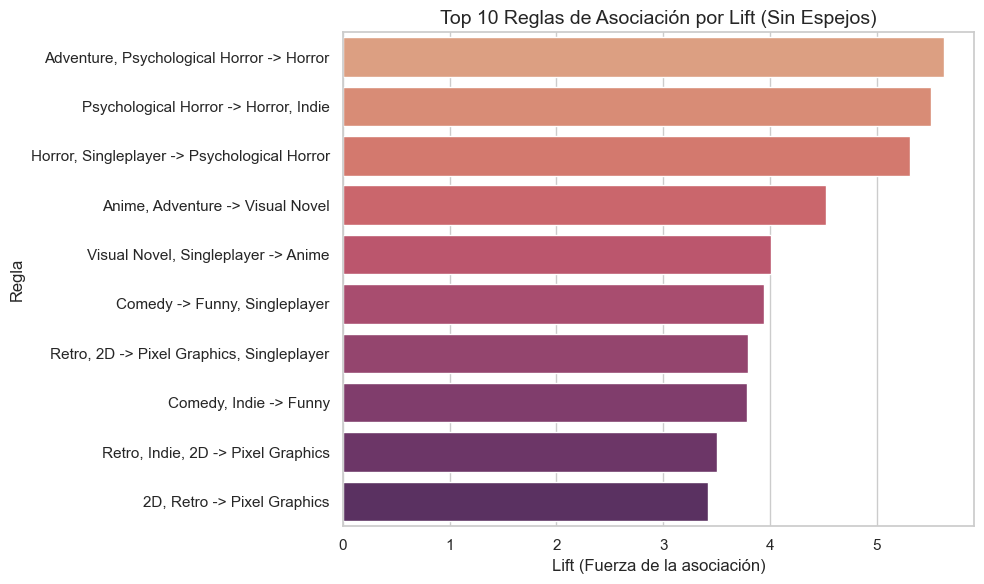

In [234]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# PREPARACIÓN DE DATOS PARA LA GRÁFICA (Sin reglas espejo)
# ==============================================================================
# Usa reglas_complejas o reglas_interesantes según la que prefieras graficar
plot_rules = reglas_complejas.copy() 

# Creamos la columna temporal solo para filtrar las reglas espejo
plot_rules['itemset_union'] = plot_rules.apply(lambda row: frozenset(row['antecedents'] | row['consequents']), axis=1)

# Ordenamos por lift y confianza
plot_rules = plot_rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

# Eliminamos duplicados basados en la unión, para que solo quede una dirección de la regla
plot_rules = plot_rules.drop_duplicates(subset=['itemset_union']).drop(columns=['itemset_union'])

# Tomamos el Top 10
top_rules = plot_rules.head(10)

# ==============================================================================
# GRÁFICA
# ==============================================================================
plt.figure(figsize=(10, 6))

# Corregido el warning de Seaborn agregando hue='rule' y legend=False
sns.barplot(data=top_rules, x='lift', y='rule', hue='rule', palette='flare', legend=False)

plt.title('Top 10 Reglas de Asociación por Lift (Sin Espejos)', fontsize=14)
plt.xlabel('Lift (Fuerza de la asociación)', fontsize=12)
plt.ylabel('Regla', fontsize=12)
plt.tight_layout()
plt.show()


### 3.2 Asociación Orientada a Resultados: ¿Qué hace a un juego "Overwhelmingly Positive"?

El análisis de asociación tradicional aplicado únicamente a géneros y etiquetas presenta una limitación analítica: los resultados tienden a reconstruir la arquitectura y jerarquía de la base de datos de Steam (ej. asociando subgéneros con sus géneros principales) en lugar de revelar información de negocio accionable. 

Para transformar esta sección en un motor de _insights_ reales, cambiaremos el enfoque. En lugar de buscar cómo se asocian las etiquetas entre sí, convertiremos la calificación **"Overwhelmingly Positive"** (Extremadamente Positivos) en nuestra **variable objetivo** tratándola como una característica binaria (One-Hot Encoding). 

Al forzar al algoritmo a buscar únicamente reglas donde el consecuente sea el éxito crítico del juego, descubriremos **qué nichos, mecánicas o combinaciones específicas de géneros están logrando la mayor aclamación por parte de la comunidad de jugadores.**


In [235]:
# 1. Preparación de datos: Géneros y Etiquetas limpios
binary_cols = [col for col in df.columns if col.startswith('genre_') or col.startswith('tag_')]
df_binary = df[binary_cols].copy()
df_binary.columns = [col.replace('genre_', '').replace('tag_', '') for col in df_binary.columns]
df_binary = df_binary.T.groupby(level=0).max().T

# 2. Creación de la variable objetivo (Target)
objetivo = 'Overwhelmingly Positive'
# Creamos una columna binaria: 1 si es Overwhelmingly Positive, 0 si no lo es
df_binary[objetivo] = (df['review_score_cat'] == objetivo).astype(int)

# Seleccionamos los 50 géneros más frecuentes + nuestra columna objetivo
top_elements = df_binary.drop(columns=[objetivo]).sum().sort_values(ascending=False).head(50).index.tolist()
columnas_finales = top_elements + [objetivo]
df_objetivo_binario = df_binary[columnas_finales]

# 3. Ejecución de Apriori
print("⌛ Calculando patrones que llevan al éxito crítico... ")
from mlxtend.frequent_patterns import apriori, association_rules

# Bajamos ligeramente el min_support a 0.02 o 0.03 porque los 'Overwhelmingly Positive' son más escasos
frequent_itemsets_obj = apriori(df_objetivo_binario.astype(bool), min_support=0.02, use_colnames=True)

# Generamos las reglas
rules_obj = association_rules(frequent_itemsets_obj, metric="lift", min_threshold=1.0)
print(f"✅ Algoritmo finalizado. Reglas totales encontradas: {len(rules_obj)}")


⌛ Calculando patrones que llevan al éxito crítico... 
✅ Algoritmo finalizado. Reglas totales encontradas: 49592


In [236]:
# 4. Filtrado del Objetivo
# Función para verificar si el consecuente de la regla es ÚNICAMENTE nuestro objetivo
def lleva_al_exito(consequents):
    return len(consequents) == 1 and objetivo in consequents

# Aplicamos el filtro a las reglas
reglas_exito = rules_obj[rules_obj['consequents'].apply(lleva_al_exito)].copy()

# Ordenamos por Confianza (Probabilidad de ser Overwhelmingly Positive dado ese género) 
# y por Lift (Qué tanto mayor es esa probabilidad comparada con un juego al azar)
reglas_exito = reglas_exito.sort_values(by=['confidence', 'lift'], ascending=[False, False])

# Formateo de texto para visualización
reglas_exito['antecedents_str'] = reglas_exito['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_exito['rule'] = reglas_exito['antecedents_str'] + " -> " + objetivo

print(f"🏆 Se encontraron {len(reglas_exito)} combinaciones de mecánicas que favorecen críticas 'Overwhelmingly Positive'.")

# Visualizamos el Top 15 de nichos más exitosos
display(reglas_exito[['rule', 'support', 'confidence', 'lift']].head(15))


🏆 Se encontraron 14 combinaciones de mecánicas que favorecen críticas 'Overwhelmingly Positive'.


,rule,support,confidence,lift
4188,"Story Rich, Singleplayer -> Overwhelmingly Pos...",0.020009,0.098914,1.671221
407,Story Rich -> Overwhelmingly Positive,0.024310,0.095764,1.618008
3518,"Adventure, Singleplayer -> Overwhelmingly Posi...",0.028237,0.079757,1.347554
10460,"Singleplayer, Adventure, Indie -> Overwhelming...",0.020290,0.076435,1.291432
4032,"2D, Singleplayer -> Overwhelmingly Positive",0.022721,0.073894,1.248491
1900,"2D, Indie -> Overwhelmingly Positive",0.023796,0.072383,1.222971
223,Adventure -> Overwhelmingly Positive,0.034549,0.069691,1.177475
357,2D -> Overwhelmingly Positive,0.027396,0.069325,1.171288
1176,"Singleplayer, Indie -> Overwhelmingly Positive",0.035297,0.069158,1.168478
157,Singleplayer -> Overwhelmingly Positive,0.046657,0.068179,1.151929
